Process: EDA --> Preprocessing --> baseline model --> model selection (CV) --> Tuning(GridSearchCV) --> final evaluation --> inference.

**1. Setup**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

import joblib

In [3]:
# Display Configurations
pd.set_option("display.max_columns", None)

# Visualization Config
sns.set_theme(style='darkgrid', context='notebook')

# Project Constants
RANDOM_STATE = 42
CSV_PATH = "../Data/housing.csv"
TARGET_COL = "median_house_value"

**2. Load Data**

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
df.shape

(20640, 10)

In [6]:
df.head().T

,0,1,2,3,4
longitude,-122.23,-122.22,-122.24,-122.25,-122.25
latitude,37.88,37.86,37.85,37.85,37.85
housing_median_age,41.0,21.0,52.0,52.0,52.0
total_rooms,880.0,7099.0,1467.0,1274.0,1627.0
total_bedrooms,129.0,1106.0,190.0,235.0,280.0
population,322.0,2401.0,496.0,558.0,565.0
households,126.0,1138.0,177.0,219.0,259.0
median_income,8.3252,8.3014,7.2574,5.6431,3.8462
median_house_value,452600.0,358500.0,352100.0,341300.0,342200.0
ocean_proximity,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY


**3. Exploratory Data Analysis (EDA)**

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**Column details:**

1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
# missing values 
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target Columns: ", TARGET_COL)
print("Categorical Columns: ", cat_cols)
print("Numerical Columns: ", num_cols)

Target Columns:  median_house_value
Categorical Columns:  ['ocean_proximity']
Numerical Columns:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


**Note: total_bedrooms has missing values**

In [11]:
# duplicates
df.duplicated().sum()

0

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


**Data Visulization**

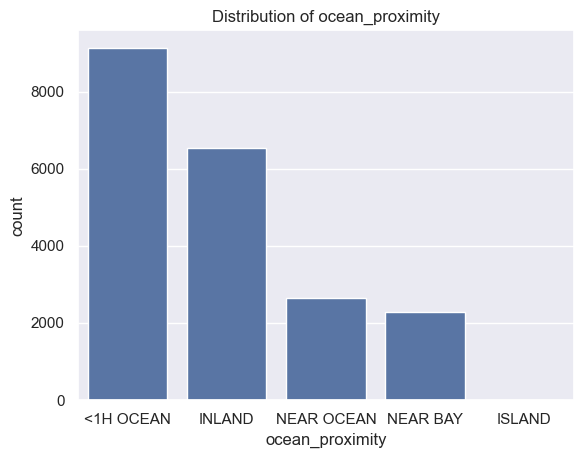

In [13]:
# Countplot for categorical columns
for col in cat_cols:
    plt.Figure(figsize=(7,5))
    sns.countplot(x=col, data = df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

In [14]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


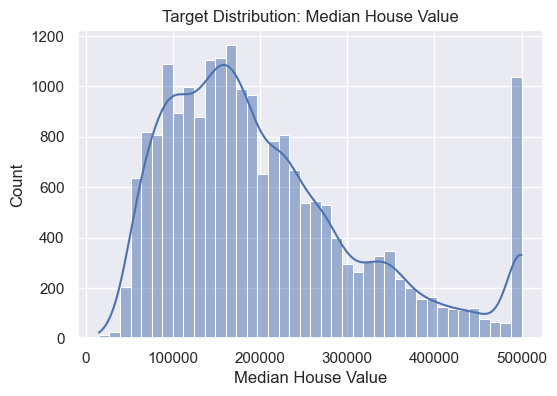

In [15]:
# Target column distibution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [16]:
df[TARGET_COL].value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
359200.0      1
54900.0       1
377600.0      1
81200.0       1
47000.0       1
Name: count, Length: 3842, dtype: int64

**Observation:**
The target variable (`median_house_value`) exhibits a right-skewed distribution with a clear upper cap around 500,000. A large number of observations are concentrated at this limit, indicating a ceiling effect where higher values are truncated. This may impact model performance for high-value predictions.

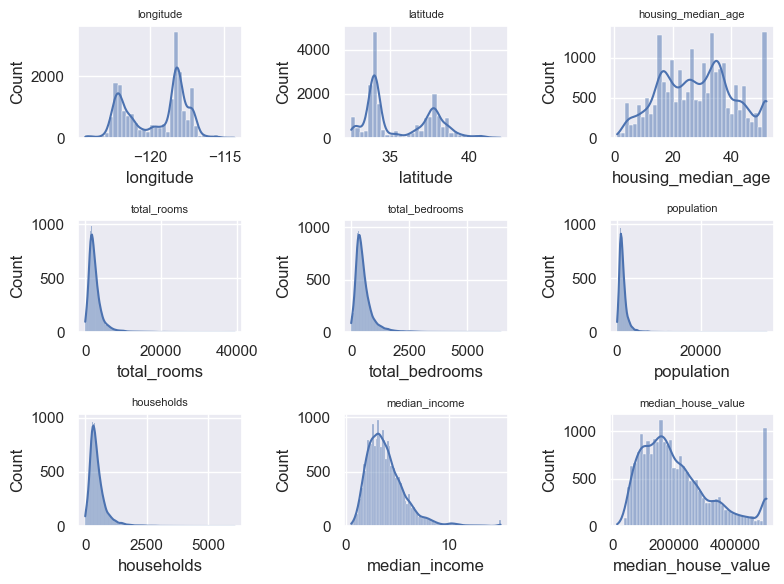

In [17]:
# Histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

- Most numerical features show right-skewed distributions.
- Some features contain extreme outliers.
- A few variables appear normally distributed.
- Log transformation may help stabilize variance.

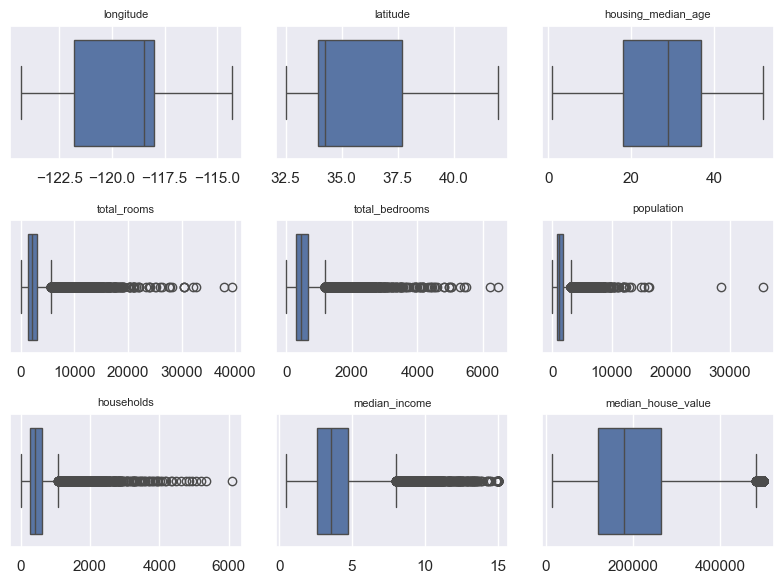

In [18]:
# Outliers anaysis - Boxplot
fig, axes = plt.subplots(3,3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    axes[i].set_xlabel("")

fig.tight_layout()
fig.show()

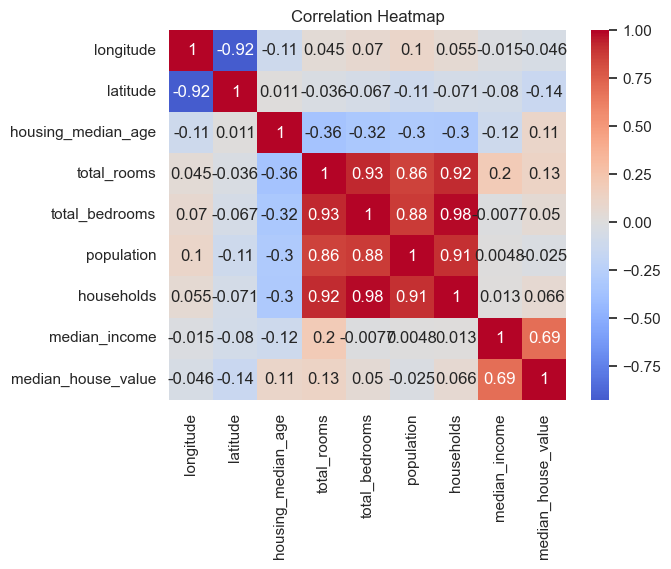

In [19]:
# identify presence of  highly correlated columns & feature relationships
plt.Figure(figsize=(10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# Correlation wiht target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=True)
print("\nCorrelation with Target:")
print(corr_with_target)


Correlation with Target:
latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64


---

🔍 Key Insights from EDA
- Dataset has 9 numeric + 1 categorical feature (ocean_proximity)
- Only total_bedrooms has missing values (~1% of rows)
- Target (median_house_value) is right-skewed and capped at $500,001 (data limitation)
- Several features show strong skew and outliers
- median_income is the strongest predictor of house value
- High multicollinearity among room and population features → addressed via ratio features

---

🛠️ Preprocessing & Feature Engineering
- Ratio features: rooms_per_household, bedrooms_per_room, population_per_household
- KMeans clustering on lat/lon → location_cluster (improves linear models significantly)
- Median imputation for missing values
- One-hot encoding for ocean_proximity and location_cluster
- StandardScaler for numerical features
- All steps inside sklearn Pipeline to prevent data leakage

📊 Evaluation Plan
- Baseline model → CV model selection → GridSearchCV tuning
- Primary metric: RMSE — secondary: MAE and R²
- Final evaluation only on held-out test set

---

**4. Data Preprocessing**

- Target is right-skewed
- Capped at 500k
- Log transform tested but removed
- Ratio features improved performance
- KMeans clustering improved linear models

In [21]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [22]:
# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [23]:
X.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,6.238137,0.155797,2.109842


In [24]:
y.head(2)

0    452600.0
1    358500.0
Name: median_house_value, dtype: float64

In [25]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=RANDOM_STATE
)

In [26]:
class KMeansCluster(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X[["latitude", "longitude"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["location_cluster"] = self.kmeans_.predict(X[["latitude", "longitude"]]).astype(str)
        return X

In [27]:
print("Train shape",X_train.shape)
print("Test shape",X_test.shape)

Train shape (16512, 12)
Test shape (4128, 12)


**Preprocessing Pipeline**

In [28]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_features.append("location_cluster")

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Preprocessing Pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features: ['ocean_proximity', 'location_cluster']


**5. Baseline model (No CV, No Tuning)**

In [29]:
baseline_pipe = Pipeline(
    steps=[
        ("cluster",    KMeansCluster(n_clusters=10, random_state=RANDOM_STATE)),
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [30]:
# Preprocess the data and train the baseline model
baseline_pipe.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cluster', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_clusters,10
,random_state,42
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

**Evaluation of baseline model**

In [31]:
test_baseline_pred = baseline_pipe.predict(X_test)

In [32]:
test_baseline_rmse = root_mean_squared_error(y_test,test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2 = r2_score(y_test,test_baseline_pred)

print("\n=== TEST BASELINE METRICES (LinerRegression) ===")
print(f"RMSE: {test_baseline_rmse}")
print(f"MAE: {test_baseline_mae}")
print(f"R2: {test_baseline_r2}")


=== TEST BASELINE METRICES (LinerRegression) ===
RMSE: 67521.50573353138
MAE: 48256.14897990155
R2: 0.6520816163329755


**6. Model Selection & Optimization**

In [33]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "HistGB": HistGradientBoostingRegressor(),
    "Xgboost": XGBRegressor(random_state=RANDOM_STATE, verbosity=0)

}

In [34]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [35]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [36]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("cluster",    KMeansCluster(n_clusters=10, random_state=RANDOM_STATE)),
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(
            pipe,
            X_train, y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1
    )
    rows.append(
        {
            "model":name,
            "cv_rmse": -scores["test_rmse"].mean(),
            "cv_mae": -scores["test_mae"].mean(),
            "cv_r2": scores["test_r2"].mean()
        }
    )

# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparsion ===")
print(cv_results)

=== CV Model Comparsion ===
              model       cv_rmse        cv_mae     cv_r2
4            HistGB  46885.346554  31236.687353  0.835492
5           Xgboost  47314.406249  30946.077231  0.832499
3      RandomForest  49739.899097  32549.255143  0.814862
1             Ridge  66711.532072  47875.183922  0.666753
2             Lasso  66722.502235  47879.306770  0.666647
0  LinearRegression  66724.484186  47879.969521  0.666628


In [37]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,46885.346554,31236.687353,0.835492
5,Xgboost,47314.406249,30946.077231,0.832499
3,RandomForest,49739.899097,32549.255143,0.814862
1,Ridge,66711.532072,47875.183922,0.666753
2,Lasso,66722.502235,47879.306770,0.666647
0,LinearRegression,66724.484186,47879.969521,0.666628


**BEST MODEL : HistGradientBosstinRegressor**

**7. Hyperparameter Tuning**

In [38]:
hgb_pipe = Pipeline(
    steps=[
        ("cluster",    KMeansCluster(n_clusters=10, random_state=RANDOM_STATE)),
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [39]:
# Hyperparameters Combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [40]:
grid = GridSearchCV(
    estimator= hgb_pipe,
    param_grid= param_grid,
    cv = cv,
    scoring= "neg_root_mean_squared_error",
    n_jobs= -1,
    verbose= 1,
)

In [41]:
# perform grid search 
grid.fit(X_train,y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls 

In [42]:
print("\n=== TUNED HistGB (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED HistGB (CV) ===
Best CV RMSE: 46140.380993737286
Best params: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


**8. Final Evalution**

In [43]:
best_model = grid.best_estimator_

**train**

In [44]:
train_final_pred = best_model.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE: 34062.983
MAE : 23219.292
R2  : 0.913


**test**

In [45]:
test_final_pred = best_model.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Test Performance ===
RMSE: 45219.895
MAE : 29702.235
R2  : 0.844


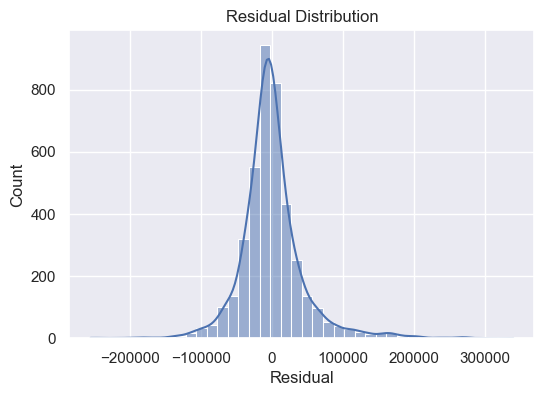

In [46]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

**9. train whole dataset**

In [47]:
final_model = grid.best_estimator_

# Train on full data
final_model.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cluster', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_clusters,10
,random_state,42
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

**10. joblib save model.pkl**

In [ ]:
# Check what's inside before saving
print(final_model)
print()

# Confirm best params are applied
print("Best Params:", grid.best_params_)
print()

Pipeline(steps=[('cluster', KMeansCluster()),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'rooms_per_household',
                

In [ ]:
# joblib.dump()
joblib.dump(final_model, 'final_model.joblib')

['final_model.joblib']

## Key Decisions & Findings

| Decision | Outcome |
|---|---|
| Dropped $500k capped rows | R² dropped 0.844 → 0.824, reverted |
| Added ratio features | R² improved 0.830 → 0.844 |
| KMeans location clustering | Improved linear models, neutral for trees |
| Log transform on target | No improvement, reverted, removed |